Goals:
   - Use Digital Archaeology skills and fundamentals to analyze texts for certain patterns and trends.

Idea:
   - Find a certain work that has multiple translations and compare the words contained in each translation. 

Examples:
   - Homer's Odyssey
  -  The Bible
   - Other Old Greek/Roman works
  -  Shakespeare modern rewrites

- S. Butler
  - Year: 1900
  - Translation
  - Ulysses
- A. Pope
  - Year: 1725-1726
  - Translation
  - Ulysses
- S. H. Butcher, A. Lang
  - Year: 1879
  - Translation
  - Odysseus
- G. Chapman
  - Year: 1614-1615
  - Translation 
  - Ulysses 
- W. Cowper
  - Year: 1791
  - Translation
  - Ulysses 
- M. E. Burt
  - Year: 1898
  - Rewrite
  - Odysseus 
- H. L. Havell
  - Year: c. 1900-1905
  - Rewrite
  - Odysseus 
- G. Thorne
  - Year: 1902
  - Rewrite
  - Ulysses 
- A. J. Church
  - Year: 1906
  - Rewrite
  - Ulysses 
- K. F. Becker
  - Year: 1912
  - Rewrite 
  - Ulysses

In [20]:
import re
import requests
from bs4 import BeautifulSoup

# Add the Project Gutenberg links for the books you want to compare.
book_urls = {
    "S. Butler": "https://www.gutenberg.org/cache/epub/1727/pg1727.txt",
    "A. Pope": "https://www.gutenberg.org/cache/epub/3160/pg3160.txt",
    "S. H. Butcher & A. Lang": "https://www.gutenberg.org/cache/epub/1728/pg1728.txt",
    "G. Chapman": "https://www.gutenberg.org/cache/epub/48895/pg48895.txt",
    "W. Cowper": "https://www.gutenberg.org/cache/epub/24269/pg24269.txt",
    "M. E. Burt": "https://www.gutenberg.org/cache/epub/24856/pg24856.txt",
    "H. L. Havell": "https://www.gutenberg.org/cache/epub/13725/pg13725.txt",
    "G. Thorne": "https://www.gutenberg.org/cache/epub/41935/pg41935.txt",
    "A. J. Church": "https://www.gutenberg.org/cache/epub/6370/pg6370.txt",
    "K. F. Becker": "https://www.gutenberg.org/cache/epub/59750/pg59750.txt",
    

}


def get_word_count(url):
    response = requests.get(url, timeout=30)
    response.raise_for_status()

    text = response.text.split("*** START OF THE PROJECT GUTENBERG EBOOK", 1)[1]
    text = text.split("*** END OF THE PROJECT GUTENBERG EBOOK", 1)[0]
    # BeautifulSoup also works when Gutenberg returns plain text rather than HTML.
    text = BeautifulSoup(text, "html.parser").get_text(" ")
    words = re.findall(r"[A-Za-z]+(?:['-][A-Za-z]+)*", text.lower())
    return len(words)


word_counts = {
    title: get_word_count(url)
    for title, url in book_urls.items()
    if url.strip()
}

word_counts

{'S. Butler': 129633,
 'A. Pope': 125060,
 'S. H. Butcher & A. Lang': 142519,
 'G. Chapman': 181062,
 'W. Cowper': 117302,
 'M. E. Burt': 48588,
 'H. L. Havell': 68761,
 'G. Thorne': 23571,
 'A. J. Church': 45731,
 'K. F. Becker': 39005}

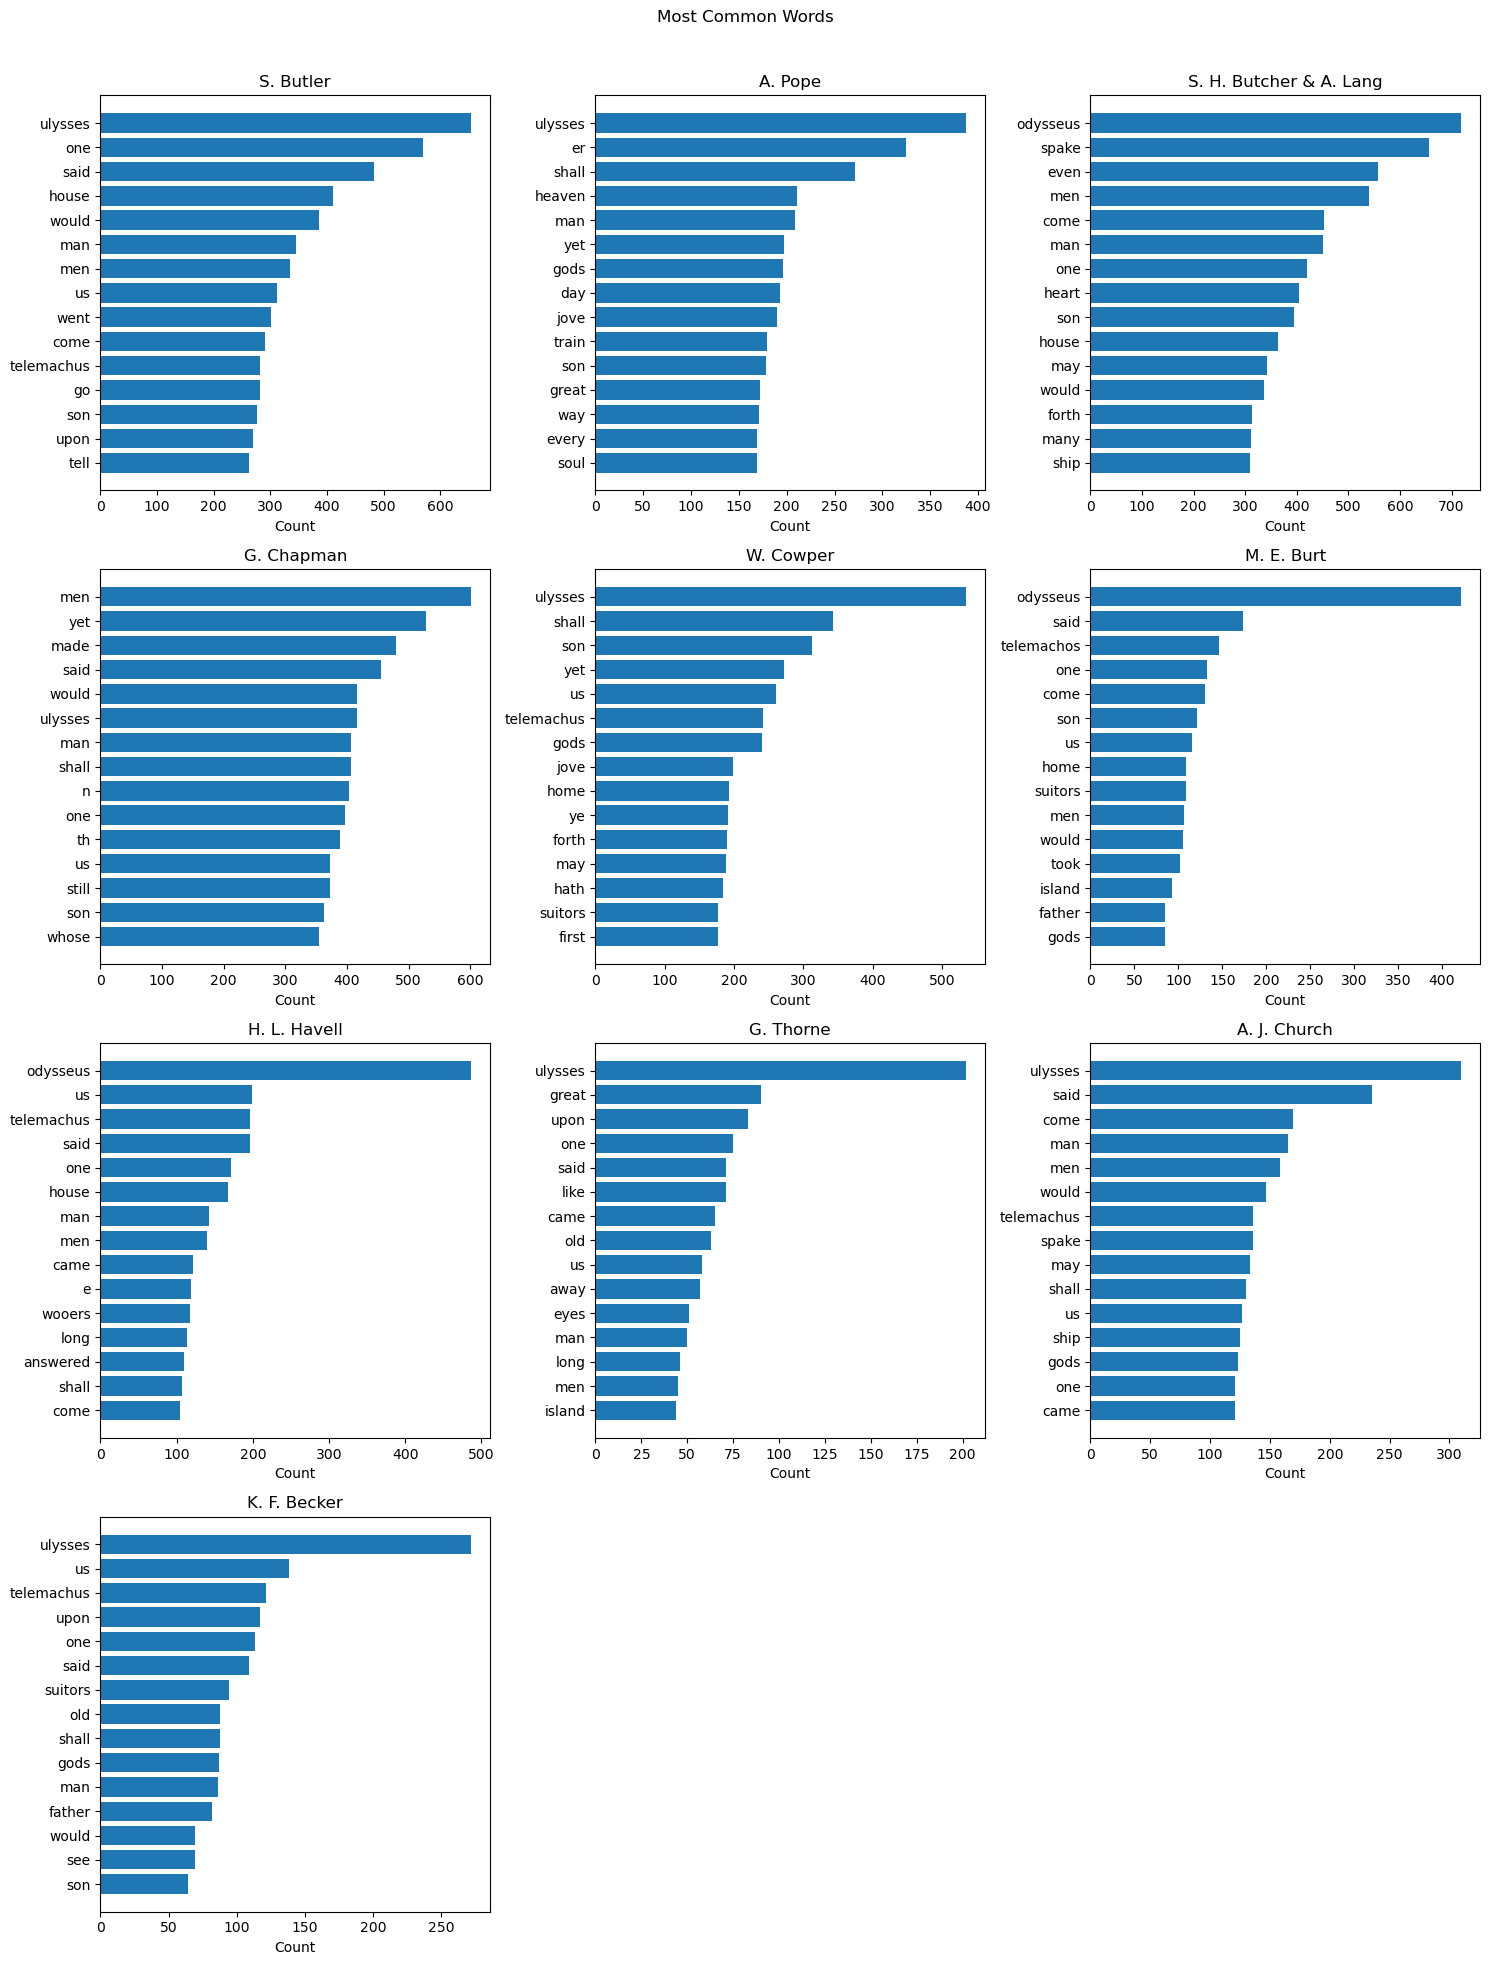

In [ ]:
from collections import Counter
import math
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

try:
    stop_words = set(stopwords.words("english"))
except LookupError:
    nltk.download("stopwords", quiet=True)
    stop_words = set(stopwords.words("english"))

stop_words.update({"thy", "thou", "thee", "thus"})


def get_word_frequencies(url):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text = response.text.split("*** START OF THE PROJECT GUTENBERG EBOOK", 1)[1]
    text = text.split("*** END OF THE PROJECT GUTENBERG EBOOK", 1)[0]
    text = BeautifulSoup(text, "html.parser").get_text(" ")
    words = re.findall(r"[A-Za-z]+(?:['-][A-Za-z]+)*", text.lower())
    return Counter(word for word in words if word not in stop_words)


book_frequencies = {
    title: get_word_frequencies(url)
    for title, url in book_urls.items()
    if url.strip()
}

columns = 3
rows = math.ceil(len(book_frequencies) / columns)
fig, axes = plt.subplots(
    rows,
    columns,
    figsize=(15, 5 * rows),
    squeeze=False,
)
axes = axes.flatten()

for axis, (title, frequencies) in zip(axes, book_frequencies.items()):
    most_common = frequencies.most_common(15)[::-1]
    words = [word for word, count in most_common]
    counts = [count for word, count in most_common]
    axis.barh(words, counts)
    axis.set_title(title)
    axis.set_xlabel("Count")

# Hide empty subplot slots when the number of books is not a multiple of three.
for axis in axes[len(book_frequencies):]:
    axis.set_visible(False)

fig.suptitle("Most Common Words")
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

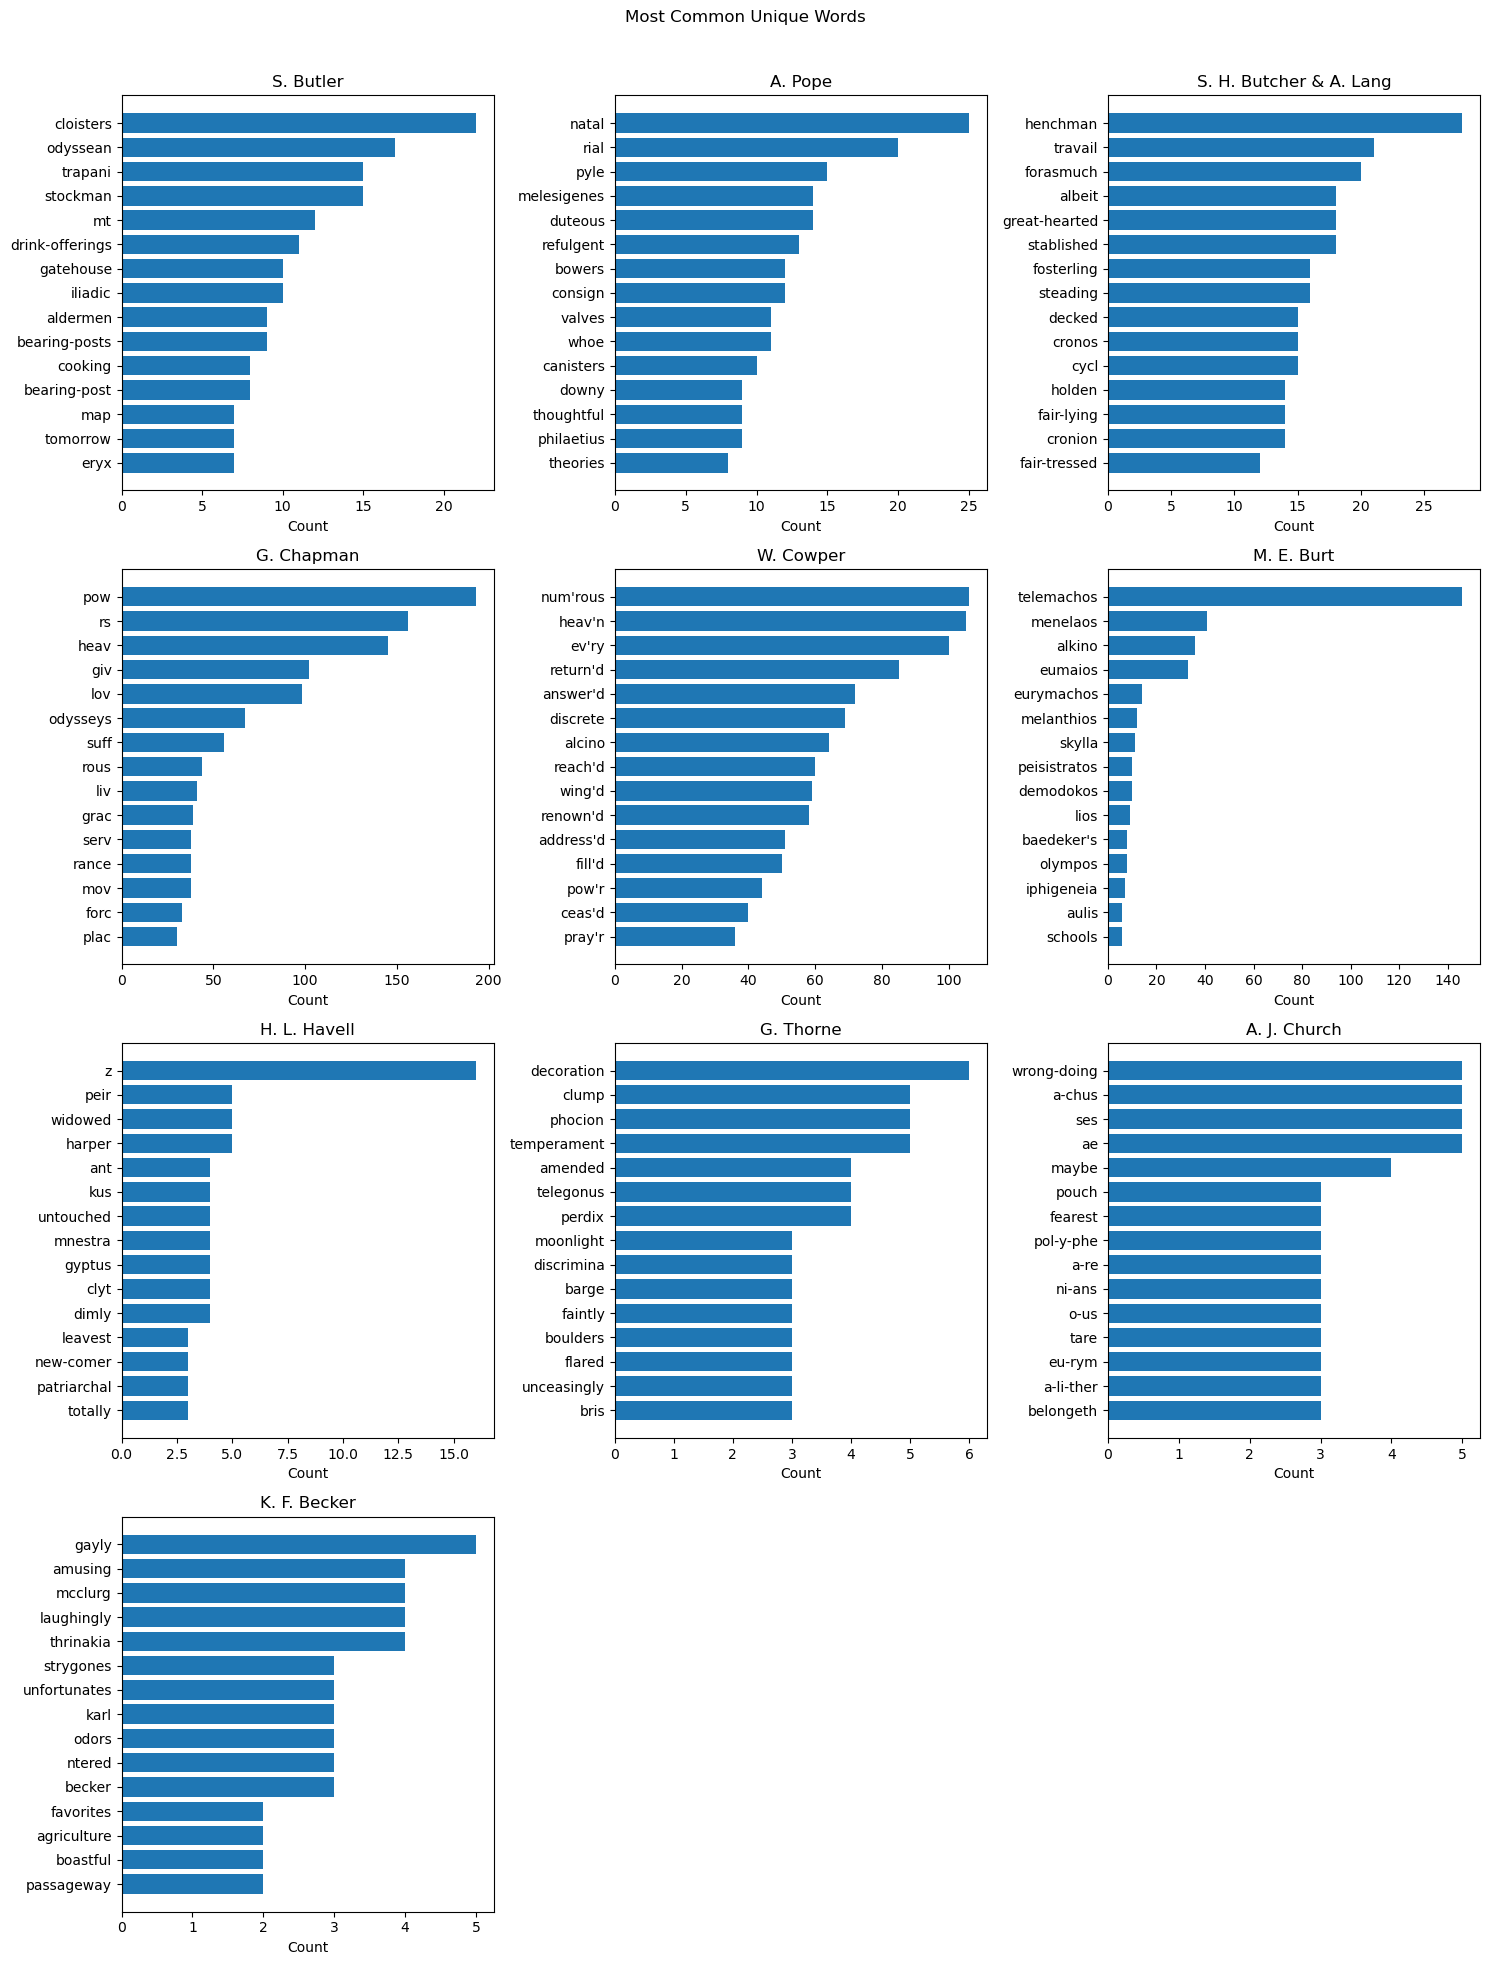

In [30]:
word_book_counts = Counter(
    word
    for frequencies in book_frequencies.values()
    for word in frequencies
)
unique_words_by_book = {
    title: {word for word in frequencies if word_book_counts[word] == 1}
    for title, frequencies in book_frequencies.items()
}

unique_frequencies_by_book = {
    title: Counter({word: frequencies[word] for word in unique_words_by_book[title]})
    for title, frequencies in book_frequencies.items()
}

columns = 3
rows = math.ceil(len(unique_frequencies_by_book) / columns)
fig, axes = plt.subplots(
    rows,
    columns,
    figsize=(15, 5 * rows),
    squeeze=False,
)
axes = axes.flatten()

for axis, (title, frequencies) in zip(axes, unique_frequencies_by_book.items()):
    most_common = frequencies.most_common(15)[::-1]
    words = [word for word, count in most_common]
    counts = [count for word, count in most_common]
    axis.barh(words, counts)
    axis.set_title(title)
    axis.set_xlabel("Count")

# Hide empty subplot slots when the number of books is not a multiple of three.
for axis in axes[len(unique_frequencies_by_book):]:
    axis.set_visible(False)

fig.suptitle("Most Common Unique Words")
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

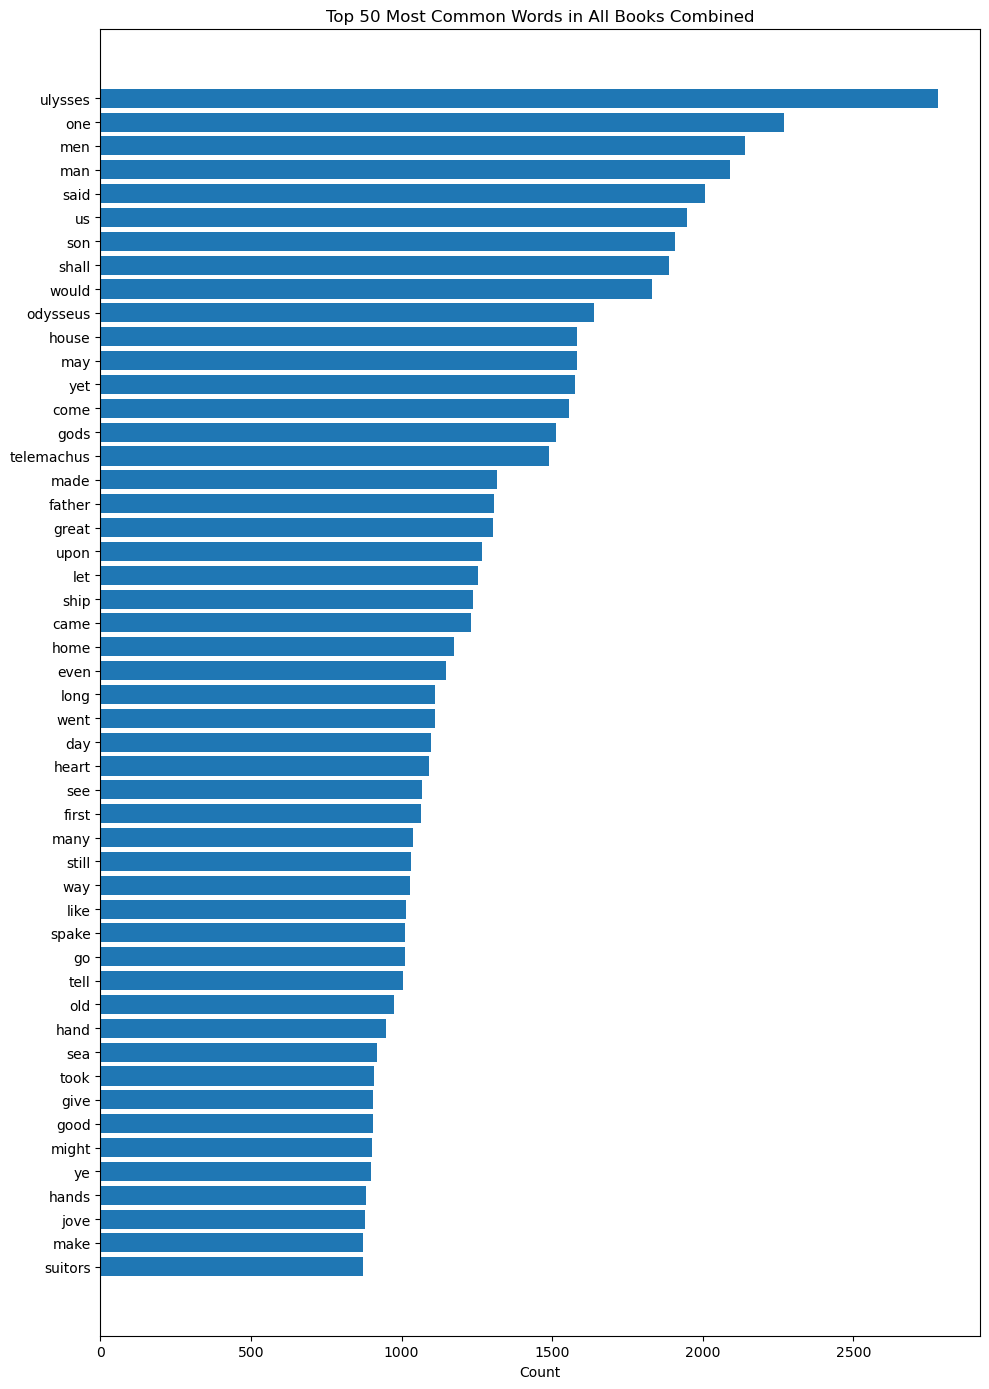

In [32]:
combined_frequencies = Counter()

for frequencies in book_frequencies.values():
    combined_frequencies.update(frequencies)

most_common_combined = combined_frequencies.most_common(50)[::-1]
words = [word for word, count in most_common_combined]
counts = [count for word, count in most_common_combined]

plt.figure(figsize=(10, 14))
plt.barh(words, counts)
plt.title("Top 50 Most Common Words in All Books Combined")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

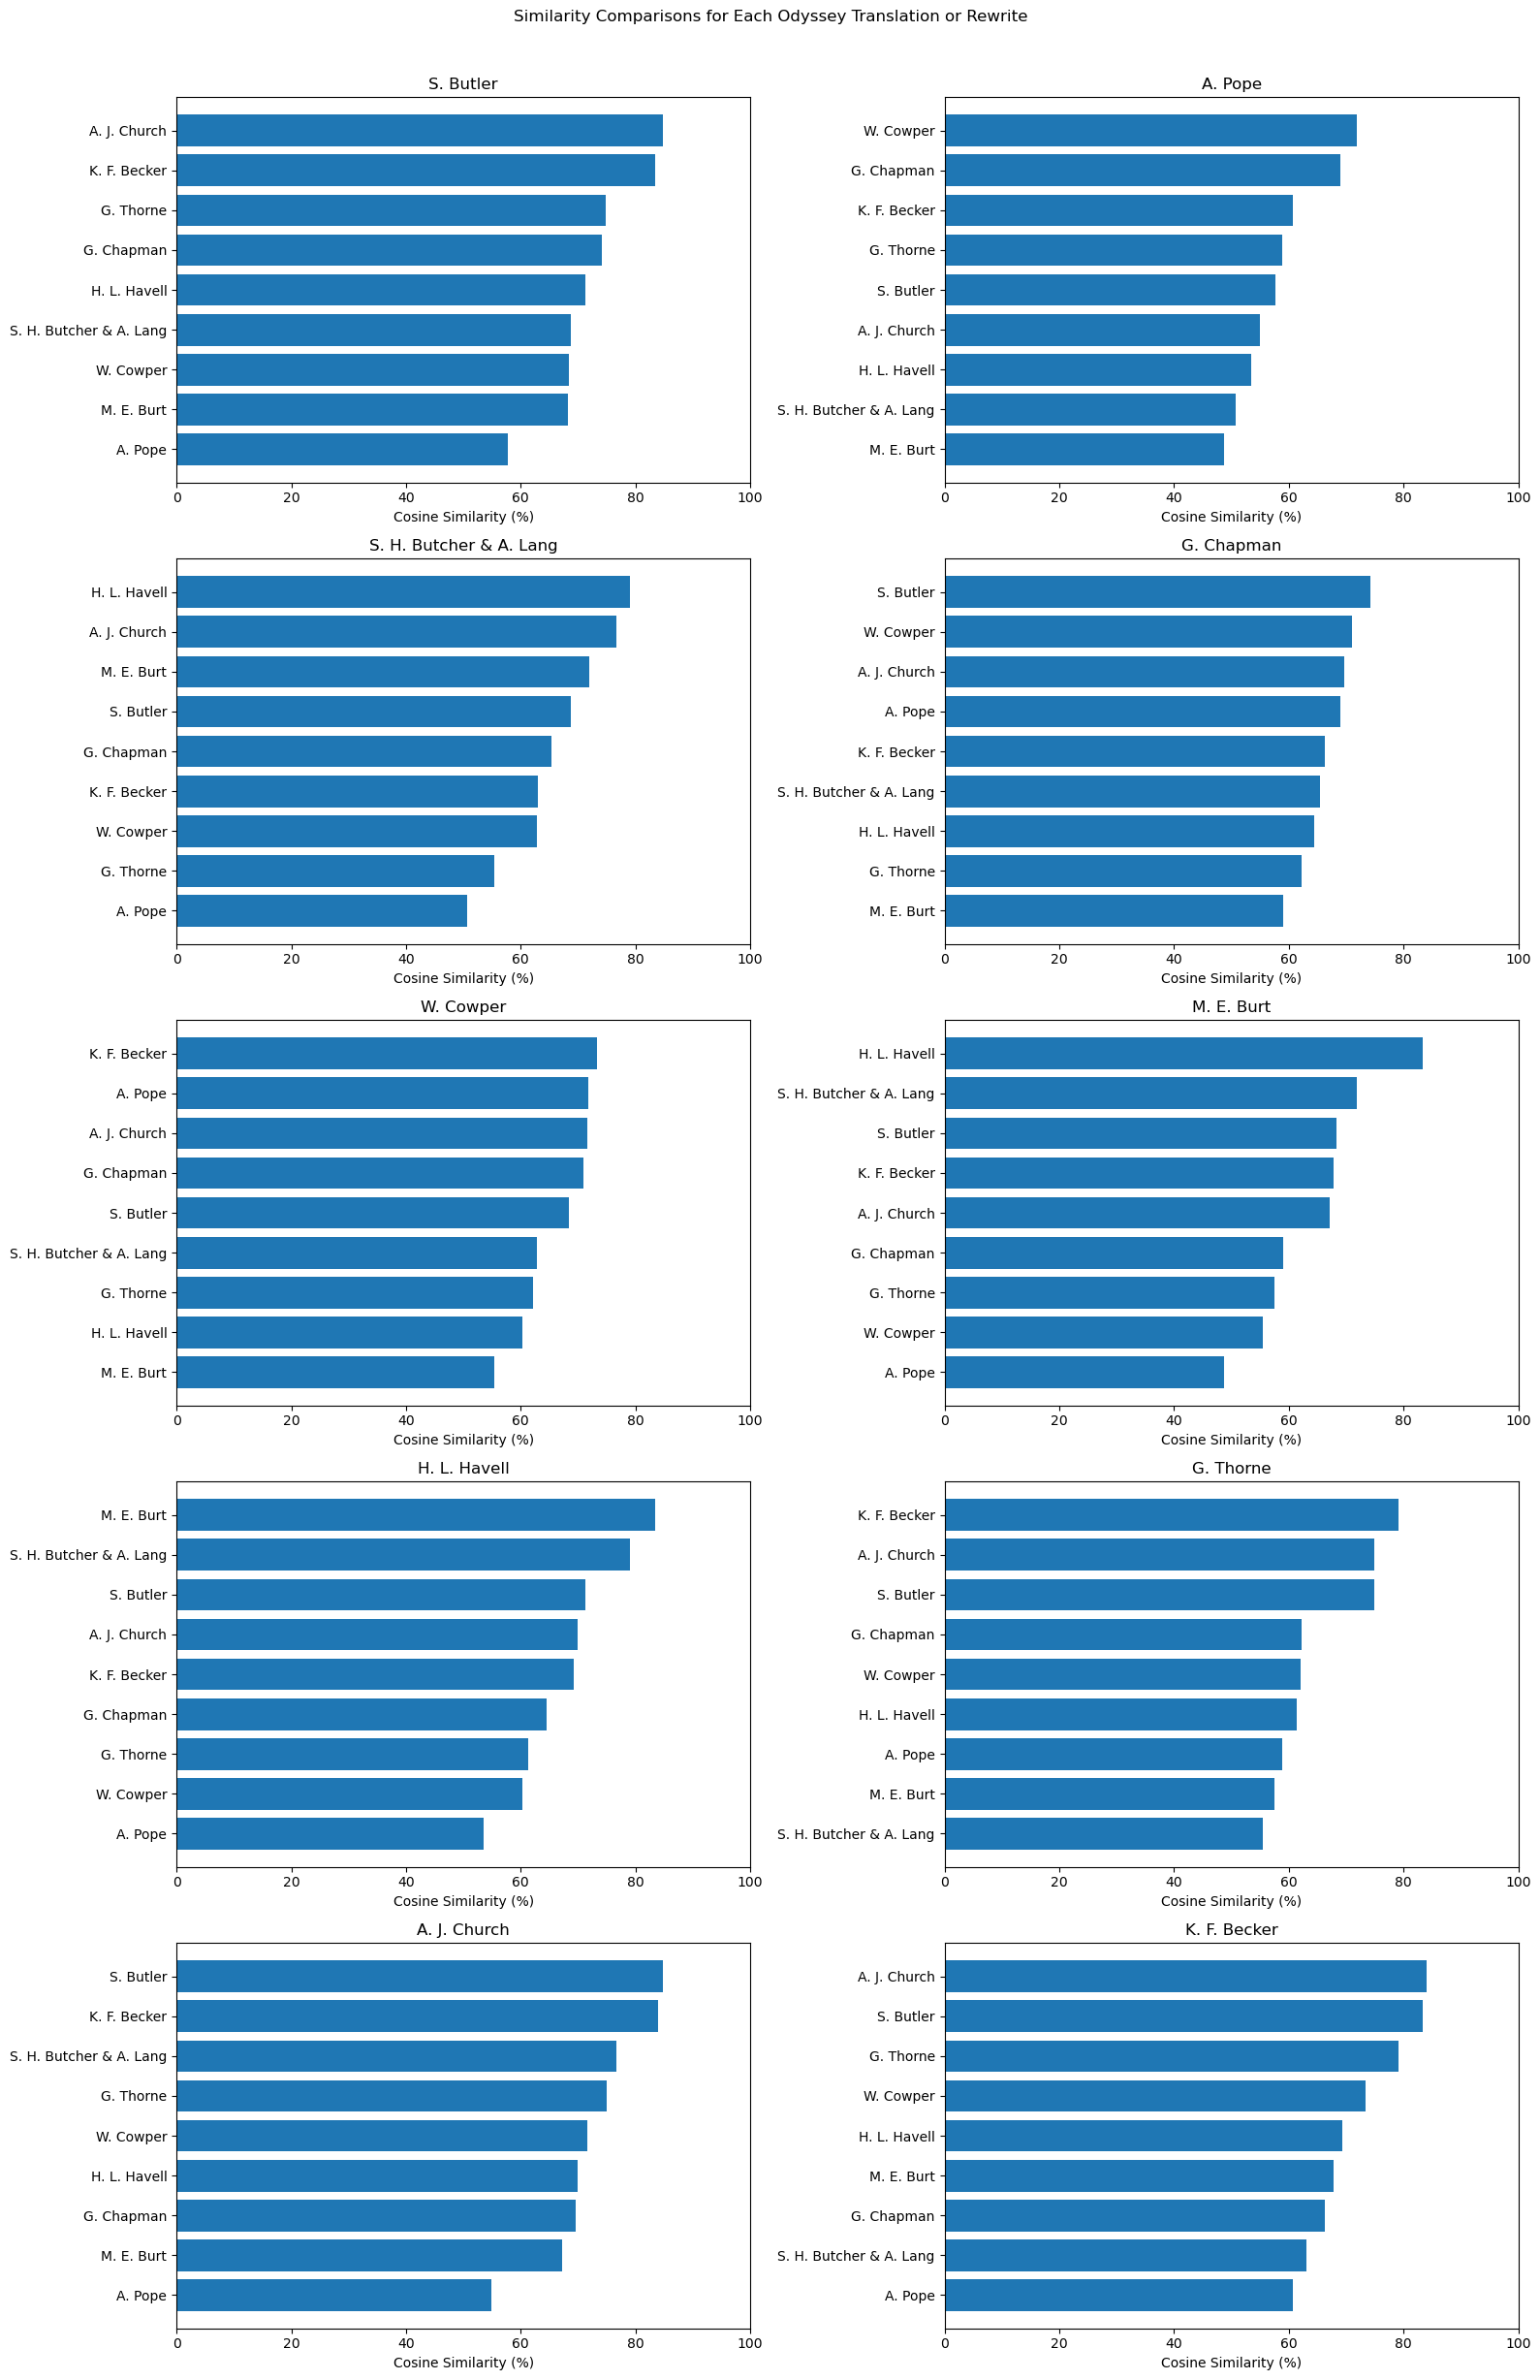

S. Butler: most similar to A. J. Church (84.77%), least similar to A. Pope (57.68%)
A. Pope: most similar to W. Cowper (71.84%), least similar to M. E. Burt (48.64%)
S. H. Butcher & A. Lang: most similar to H. L. Havell (79.10%), least similar to A. Pope (50.65%)
G. Chapman: most similar to S. Butler (74.17%), least similar to M. E. Burt (59.04%)
W. Cowper: most similar to K. F. Becker (73.30%), least similar to M. E. Burt (55.46%)
M. E. Burt: most similar to H. L. Havell (83.35%), least similar to A. Pope (48.64%)
H. L. Havell: most similar to M. E. Burt (83.35%), least similar to A. Pope (53.47%)
G. Thorne: most similar to K. F. Becker (79.13%), least similar to S. H. Butcher & A. Lang (55.42%)
A. J. Church: most similar to S. Butler (84.77%), least similar to A. Pope (54.91%)
K. F. Becker: most similar to A. J. Church (83.93%), least similar to A. Pope (60.62%)
Overall most similar: S. Butler vs. A. J. Church (84.77%)
Overall least similar: A. Pope vs. M. E. Burt (48.64%)


In [31]:
import math
from itertools import combinations


def cosine_similarity(first_frequencies, second_frequencies):
    shared_words = set(first_frequencies) & set(second_frequencies)
    dot_product = sum(
        first_frequencies[word] * second_frequencies[word]
        for word in shared_words
    )
    first_magnitude = math.sqrt(
        sum(count**2 for count in first_frequencies.values())
    )
    second_magnitude = math.sqrt(
        sum(count**2 for count in second_frequencies.values())
    )

    if first_magnitude == 0 or second_magnitude == 0:
        return 0.0

    return dot_product / (first_magnitude * second_magnitude)


similarity_percentages = {}
for first_title, second_title in combinations(book_frequencies, 2):
    similarity = cosine_similarity(
        book_frequencies[first_title],
        book_frequencies[second_title],
    )
    similarity_percentages[(first_title, second_title)] = similarity * 100

similarities_by_book = {title: {} for title in book_frequencies}
for (first_title, second_title), percentage in similarity_percentages.items():
    similarities_by_book[first_title][second_title] = percentage
    similarities_by_book[second_title][first_title] = percentage

columns = 2
rows = math.ceil(len(similarities_by_book) / columns)
fig, axes = plt.subplots(
    rows,
    columns,
    figsize=(16, 5 * rows),
    squeeze=False,
)
axes = axes.flatten()

for axis, (title, comparisons) in zip(axes, similarities_by_book.items()):
    sorted_comparisons = sorted(
        comparisons.items(),
        key=lambda item: item[1],
    )
    comparison_titles = [book_title for book_title, percentage in sorted_comparisons]
    comparison_percentages = [
        percentage for book_title, percentage in sorted_comparisons
    ]

    axis.barh(comparison_titles, comparison_percentages)
    axis.set_title(title)
    axis.set_xlabel("Cosine Similarity (%)")
    axis.set_xlim(0, 100)

for axis in axes[len(similarities_by_book):]:
    axis.set_visible(False)

fig.suptitle("Similarity Comparisons for Each Odyssey Translation or Rewrite")
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

for title, comparisons in similarities_by_book.items():
    most_similar_title, most_similar_percentage = max(
        comparisons.items(),
        key=lambda item: item[1],
    )
    least_similar_title, least_similar_percentage = min(
        comparisons.items(),
        key=lambda item: item[1],
    )
    print(
        f"{title}: most similar to {most_similar_title} "
        f"({most_similar_percentage:.2f}%), "
        f"least similar to {least_similar_title} "
        f"({least_similar_percentage:.2f}%)"
    )

overall_most_similar_pair, overall_most_similar_percentage = max(
    similarity_percentages.items(),
    key=lambda item: item[1],
)
overall_least_similar_pair, overall_least_similar_percentage = min(
    similarity_percentages.items(),
    key=lambda item: item[1],
)
print(
    f"Overall most similar: {overall_most_similar_pair[0]} vs. "
    f"{overall_most_similar_pair[1]} "
    f"({overall_most_similar_percentage:.2f}%)"
)
print(
    f"Overall least similar: {overall_least_similar_pair[0]} vs. "
    f"{overall_least_similar_pair[1]} "
    f"({overall_least_similar_percentage:.2f}%)"
)